# Closed-form GMM covariance Tikhonov — matched rescaled SongUNet protocol

**Purpose.** Provide the closed-form reference for
`songunet_covariance_tikhonov.ipynb`. This notebook changes exactly one thing: the trained
SongUNet is replaced by the exact empirical-GMM denoiser. Everything that changes a number
is matched to the SongUNet run:

- the same first two rescaled Matérn fields (`seed=42`, $D_-=\sqrt{340}$);
- the same 25 arms: gate, isotropic, empirical covariance estimated with
  $n\in\{2,8,16,32\}$, and population covariance;
- the same $c\in\{0.003,0.01,0.03,0.1\}$, $M^2$ budget matching, null-mode rule,
  $\sigma_{\max}=80$, 40-step deterministic Heun sampler, latent seed, sample count,
  bands, and memorization metric.

There is **no network training** and no model-size axis. The $n=8,16,32$ fields are used
only to estimate the covariance spectrum; the GMM target remains the same empirical measure
on the two training fields.

With forward-normalized FFT and pixel-sum reduction, define
$w(k)=\widetilde\lambda^{-1}(k)/M$, where
$\sum_k\widetilde\lambda^{-1}(k)=M^2$. The regularized exact denoiser is

$$D_{c,k}(x,\sigma)=x_k+
  \frac{\sigma^2}{\sigma^2+c\,w(k)}\,[\mu_\sigma(x)-x]_k,$$

where $\mu_\sigma(x)$ is the posterior mean under the two-component empirical Gaussian
mixture. Isotropic Tikhonov is $w(k)=1$.


In [1]:
import os, sys, math, time
import numpy as np
import torch
import matplotlib

if not os.environ.get('DISPLAY') and not hasattr(sys, 'ps1'):
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from device_utils import resolve_device
from multiband_data_utils import generate_multiband_dataset_postmask, make_knrm_grid
from memorization_metrics import RingMetricContext

DEVICE = resolve_device()
GRID = 128
M = GRID * GRID
N_TRAIN = 2
SMOKE = os.environ.get('FIELD_SMOKE', '0').strip().lower() not in ('0', '', 'false', 'no')

CFG = dict(
    sigma_min=0.002, sigma_max=80.0, rho=7,
    num_steps=40, S_churn=0.0, S_min=0.0,
    S_max=float('inf'), S_noise=1.0,
    n_eval_samples=100, eval_batch=25,
    latent_seed=42, rel_threshold=0.3,
    n_rand_ref=1,  # exact at n_train=2 with exclude_nn=True
)
C_VALUES = [3e-3, 1e-2, 3e-2, 0.1]
ESTIMATION_NS = [2, 8, 16, 32]
if SMOKE:
    CFG.update(num_steps=8, n_eval_samples=8, eval_batch=8)
    C_VALUES = [1e-2]
    ESTIMATION_NS = [2]

results_dir = os.environ.get('FIELD_RESULTS_DIR', os.path.join(repo_root, 'results', 'data'))
fig_dir = os.environ.get('FIELD_FIG_DIR', os.path.join(repo_root, 'results', 'figures'))
os.makedirs(results_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)
run_tag = 'smoke' if SMOKE else 'full'
out_dir = os.path.join(results_dir, 'gmm_rescaled_cov_tikhonov')
os.makedirs(out_dir, exist_ok=True)
save_path = os.path.join(out_dir, f'gmm_rescaled_cov_tikhonov_{run_tag}.pt')

SAMPLER_DTYPE = torch.float32 if DEVICE.type == 'mps' else torch.float64
print(f'device={DEVICE}, sampler dtype={SAMPLER_DTYPE}, smoke={SMOKE}')
print(f'results -> {save_path}')


device=mps, sampler dtype=torch.float32, smoke=False
results -> /Users/ishittaiyer/Desktop/research-diffusion/results/data/gmm_rescaled_cov_tikhonov/gmm_rescaled_cov_tikhonov_full.pt


## Matched rescaled data

This is copied from the SongUNet notebook. The hard assertion prevents accidentally running
the old unit-scale geometry.


In [2]:
components = [
    {'name':'coarse', 'length_scale':2.0,  's':2.0, 'sigma_sq':1.0, 'band':(0.5,4.0)},
    {'name':'mid1',   'length_scale':6.0,  's':2.0, 'sigma_sq':1.0, 'band':(4.0,10.0)},
    {'name':'mid2',   'length_scale':12.0, 's':2.0, 'sigma_sq':1.0, 'band':(10.0,18.0)},
    {'name':'fine',   'length_scale':24.0, 's':2.0, 'sigma_sq':1.0, 'band':(18.0,32.0)},
]
weights = [1.0, 0.8, 0.8, 1.2]

_pool = generate_multiband_dataset_postmask(
    num_samples=200, grid_size=GRID, components=components,
    weights=weights, seed=42, normalize=True,
)
normalization_std = _pool['normalization']['std']
_base = _pool['combined'][:N_TRAIN].reshape(N_TRAIN, 1, GRID, GRID).clone().float()
D_UNIT = torch.cdist(_base.reshape(N_TRAIN, -1), _base.reshape(N_TRAIN, -1))[0, 1].item()
RECT_D_MINUS = math.sqrt(340.0)
SCALE = RECT_D_MINUS / D_UNIT
data = _base * SCALE
D_MINUS = torch.cdist(data.reshape(N_TRAIN, -1), data.reshape(N_TRAIN, -1))[0, 1].item()

assert abs(D_MINUS - RECT_D_MINUS) < 1e-3
assert abs(SCALE - 0.09920) < 5e-4
print(f'n_train={N_TRAIN}, scale={SCALE:.5f}, D_minus={D_MINUS:.4f}, data std={data.std():.5f}')


n_train=2, scale=0.09920, D_minus=18.4391, data std=0.10437


## Matched empirical and population spectra

Empirical spectra use the uncentered radially averaged periodogram. Population covariance is
analytic. The $M^2$ normalization exactly matches the total forward-FFT covariance penalty
to the pixel-sum isotropic penalty, so the scalar $c$ has the same average budget.


In [3]:
knrm = make_knrm_grid(GRID).double()
ring = knrm.round().long()
nring = int(ring.max()) + 1
cnt = torch.zeros(nring, dtype=torch.float64).index_add_(
    0, ring.flatten(), torch.ones(M, dtype=torch.float64))

def radial_avg_spectrum(fields_2d):
    P = (torch.fft.fft2(fields_2d.double(), norm='forward').abs() ** 2).mean(0)
    tot = torch.zeros(nring, dtype=torch.float64).index_add_(0, ring.flatten(), P.flatten())
    return (tot / cnt.clamp_min(1))[ring]

_pool_all = _pool['combined'].double()
lam_emp = {n: radial_avg_spectrum(_pool_all[:n] * SCALE) for n in ESTIMATION_NS}

lam_pop = torch.zeros(GRID, GRID, dtype=torch.float64)
for comp, weight_i in zip(components, weights):
    S = comp['sigma_sq'] * (knrm**2 + comp['length_scale']**2) ** (-comp['s'])
    S[0, 0] = 0.0
    lo, hi = comp['band']
    S = S * ((knrm >= lo) & (knrm < hi)).double()
    lam_pop += (weight_i**2) * S
lam_pop = lam_pop / normalization_std**2 * SCALE**2

NULL_REL_THRESHOLD = 1e-4
def build_inv_lam(lam):
    active = lam > NULL_REL_THRESHOLD * lam[lam > 0].mean()
    inv = torch.where(active, 1.0 / lam.clamp_min(1e-30), torch.zeros_like(lam))
    inv = inv * (M * M / inv.sum())
    return inv, active

inv_lam_emp = {n: build_inv_lam(lam_emp[n])[0] for n in ESTIMATION_NS}
inv_lam_pop, active_pop = build_inv_lam(lam_pop)

for name, inv in [(f'emp_n{n}', inv_lam_emp[n]) for n in ESTIMATION_NS] + [('population', inv_lam_pop)]:
    assert torch.isfinite(inv).all() and abs(inv.sum().item() / (M*M) - 1) < 1e-10
    print(f'{name:>12}: active={(inv > 0).sum().item():4d}, sum(inv_lam)={inv.sum().item():.0f}')


      emp_n2: active=3312, sum(inv_lam)=268435456
      emp_n8: active=3312, sum(inv_lam)=268435456
     emp_n16: active=3312, sum(inv_lam)=268435456
     emp_n32: active=3312, sum(inv_lam)=268435456
  population: active=3204, sum(inv_lam)=268435456


## Exact empirical-GMM denoiser

The posterior mixture weights always come from the same two training fields. Tikhonov only
filters the implied score; it does not change those weights. For covariance arms the code
uses $w(k)=\widetilde\lambda^{-1}(k)/M$, the stationary point of the exact loss implemented
by the SongUNet notebook (pixel-sum data term plus forward-FFT covariance penalty).


In [4]:
class RegularizedGMMDenoiser(torch.nn.Module):
    sigma_min = 0.0
    sigma_max = float('inf')

    def __init__(self, train_data, c=0.0, inv_lam=None):
        super().__init__()
        self.register_buffer('train_flat', train_data.reshape(train_data.shape[0], -1))
        self.c = float(c)
        if inv_lam is None:
            self.inv_lam = None
        else:
            self.register_buffer('inv_lam', inv_lam)

    def round_sigma(self, sigma):
        return torch.as_tensor(sigma)

    def forward(self, x, sigma, class_labels=None):
        shape = x.shape
        dtype, device = x.dtype, x.device
        y = self.train_flat.to(device=device, dtype=dtype)
        xf = x.reshape(shape[0], -1)
        sigma_b = torch.as_tensor(sigma, dtype=dtype, device=device).reshape(-1)
        if sigma_b.numel() == 1:
            sigma_b = sigma_b.expand(shape[0])

        d2 = ((xf[:, None, :] - y[None, :, :]) ** 2).sum(dim=-1)
        alpha = torch.softmax(-d2 / (2 * sigma_b[:, None] ** 2), dim=1)
        mu = (alpha @ y).reshape(shape)
        delta = mu - x

        if self.c == 0.0:
            return mu
        if self.inv_lam is None:
            keep = sigma_b**2 / (sigma_b**2 + self.c)
            return x + keep[:, None, None, None] * delta

        inv = self.inv_lam.to(device=device, dtype=dtype)
        delta_hat = torch.fft.fft2(delta, dim=(-2, -1), norm='forward')
        keep = sigma_b[:, None, None, None]**2 / (
            sigma_b[:, None, None, None]**2 + self.c * inv[None, None] / M)
        return x + torch.fft.ifft2(delta_hat * keep, dim=(-2, -1), norm='forward').real

# Algebra checks: c=0 is the empirical posterior mean; flat covariance equals isotropic.
_x = torch.randn(2, 1, GRID, GRID, dtype=torch.float64)
_sigma = torch.tensor(0.3, dtype=torch.float64)
_train = data.double()
_gate = RegularizedGMMDenoiser(_train, c=0.0)(_x, _sigma)
_iso = RegularizedGMMDenoiser(_train, c=0.03)(_x, _sigma)
_flat_inv = torch.full((GRID, GRID), float(M), dtype=torch.float64)  # sum = M^2
_cov_flat = RegularizedGMMDenoiser(_train, c=0.03, inv_lam=_flat_inv)(_x, _sigma)
assert torch.equal(_gate, RegularizedGMMDenoiser(_train)(_x, _sigma))
assert torch.allclose(_iso, _cov_flat, rtol=2e-12, atol=2e-12)
del _x, _sigma, _train, _gate, _iso, _flat_inv, _cov_flat
print('GMM stationary-point checks passed (c=0 and flat-covariance -> isotropic).')


GMM stationary-point checks passed (c=0 and flat-covariance -> isotropic).


## Matched EDM sampler and metrics

This is the same 40-step, $\sigma_{\max}=80$, $S_{m churn}=0$ Heun sampler used by the
SongUNet run. Sampling is deterministic conditional on the shared latent seed.


In [5]:
def edm_sampler(net, latents, class_labels=None, randn_like=torch.randn_like,
                num_steps=18, sigma_min=0.002, sigma_max=80, rho=7,
                S_churn=0, S_min=0, S_max=float('inf'), S_noise=1):
    sigma_min = max(sigma_min, net.sigma_min)
    sigma_max = min(sigma_max, net.sigma_max)
    step_indices = torch.arange(num_steps, dtype=SAMPLER_DTYPE, device=latents.device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) *
               (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([net.round_sigma(t_steps), torch.zeros_like(t_steps[:1])])
    x_next = latents.to(SAMPLER_DTYPE) * t_steps[0]
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        x_cur = x_next
        gamma = min(S_churn / num_steps, np.sqrt(2) - 1) if S_min <= t_cur <= S_max else 0
        t_hat = net.round_sigma(t_cur + gamma * t_cur)
        x_hat = x_cur + (t_hat**2 - t_cur**2).sqrt() * S_noise * randn_like(x_cur)
        denoised = net(x_hat, t_hat, class_labels).to(SAMPLER_DTYPE)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur
        if i < num_steps - 1:
            denoised = net(x_next, t_next, class_labels).to(SAMPLER_DTYPE)
            d_prime = (x_next - denoised) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)
    return x_next

@torch.no_grad()
def generate_samples(model):
    out = []
    remaining = CFG['n_eval_samples']
    chunk_i = 0
    while remaining > 0:
        batch = min(CFG['eval_batch'], remaining)
        generator = torch.Generator().manual_seed(CFG['latent_seed'] + 1000 * chunk_i)
        latents = torch.randn(batch, 1, GRID, GRID, generator=generator).to(DEVICE)
        out.append(edm_sampler(model, latents, num_steps=CFG['num_steps'],
                               sigma_min=CFG['sigma_min'], sigma_max=CFG['sigma_max'],
                               rho=CFG['rho'], S_churn=CFG['S_churn'], S_min=CFG['S_min'],
                               S_max=CFG['S_max'], S_noise=CFG['S_noise']).float().cpu())
        remaining -= batch
        chunk_i += 1
    return torch.cat(out)

bands = {comp['name']: comp['band'] for comp in components}
metric_ctx = RingMetricContext(GRID, bands, device=DEVICE)

@torch.no_grad()
def evaluate_samples(samples):
    g = samples.reshape(samples.shape[0], -1)
    t = data.reshape(data.shape[0], -1)
    d2 = torch.cdist(g, t) ** 2
    nearest = d2.min(dim=1).values.sqrt()
    nn_rel = nearest / t.norm(dim=1).mean()
    metric = metric_ctx.evaluate(samples.squeeze(1).to(DEVICE), data.squeeze(1).to(DEVICE),
                                 n_rand_ref=CFG['n_rand_ref'], exclude_nn=True,
                                 aggregate='mean_of_ratios')
    return dict(
        fraction=(nn_rel < CFG['rel_threshold']).float().mean().item(),
        nn_rel_median=nn_rel.median().item(),
        mean_ratio=metric['mean_ratio'].cpu(),
        coarse_score=metric['coarse_score'].mean().item(),
        mid1_score=metric['mid1_score'].mean().item(),
        mid2_score=metric['mid2_score'].mean().item(),
        fine_score=metric['fine_score'].mean().item(),
    )


## Run the same 25 arms

Results save after every arm and completed arms are skipped, although this closed-form sweep
is cheap compared with training SongUNet.


In [6]:
ARMS = [dict(variant='gate', c=0.0, inv_lam=None)]
ARMS += [dict(variant='isotropic', c=c, inv_lam=None) for c in C_VALUES]
for n in ESTIMATION_NS:
    ARMS += [dict(variant=f'cov_emp_n{n}', c=c, inv_lam=inv_lam_emp[n]) for c in C_VALUES]
ARMS += [dict(variant='cov_population', c=c, inv_lam=inv_lam_pop) for c in C_VALUES]

results = {}
if os.path.exists(save_path):
    saved = torch.load(save_path, map_location='cpu', weights_only=False)
    results = saved.get('results', {})
    print(f'resuming with {len(results)} completed arms')

for arm in ARMS:
    key = (arm['variant'], float(arm['c']))
    if key in results:
        print(f'skip {key}')
        continue
    t0 = time.time()
    model = RegularizedGMMDenoiser(
        data.to(DEVICE, dtype=SAMPLER_DTYPE), c=arm['c'],
        inv_lam=None if arm['inv_lam'] is None else arm['inv_lam'].to(DEVICE, dtype=SAMPLER_DTYPE),
    ).to(DEVICE)
    samples = generate_samples(model)
    stats = evaluate_samples(samples)
    stats.update(samples=samples[:16], seconds=time.time() - t0)
    results[key] = stats
    print(f"{arm['variant']:>16} c={arm['c']:<7g} frac={stats['fraction']:.2f} "
          f"coarse={stats['coarse_score']:.4f} fine={stats['fine_score']:.4f} "
          f"({stats['seconds']:.1f}s)")
    payload = dict(
        results=results, cfg=CFG, c_values=C_VALUES, estimation_ns=ESTIMATION_NS,
        data=data, scale=SCALE, D_minus=D_MINUS,
        lam_emp={n: lam_emp[n] for n in ESTIMATION_NS}, lam_pop=lam_pop,
        inv_lam_emp={n: inv_lam_emp[n] for n in ESTIMATION_NS}, inv_lam_pop=inv_lam_pop,
        null_rel_threshold=NULL_REL_THRESHOLD,
        note='Closed-form GMM matched to songunet_covariance_tikhonov.ipynb; rescaled n_train=2.',
    )
    torch.save(payload, save_path)

print(f'completed {len(results)}/{len(ARMS)} arms -> {save_path}')
assert len(results) == len(ARMS)


resuming with 25 completed arms
skip ('gate', 0.0)
skip ('isotropic', 0.003)
skip ('isotropic', 0.01)
skip ('isotropic', 0.03)
skip ('isotropic', 0.1)
skip ('cov_emp_n2', 0.003)
skip ('cov_emp_n2', 0.01)
skip ('cov_emp_n2', 0.03)
skip ('cov_emp_n2', 0.1)
skip ('cov_emp_n8', 0.003)
skip ('cov_emp_n8', 0.01)
skip ('cov_emp_n8', 0.03)
skip ('cov_emp_n8', 0.1)
skip ('cov_emp_n16', 0.003)
skip ('cov_emp_n16', 0.01)
skip ('cov_emp_n16', 0.03)
skip ('cov_emp_n16', 0.1)
skip ('cov_emp_n32', 0.003)
skip ('cov_emp_n32', 0.01)
skip ('cov_emp_n32', 0.03)
skip ('cov_emp_n32', 0.1)
skip ('cov_population', 0.003)
skip ('cov_population', 0.01)
skip ('cov_population', 0.03)
skip ('cov_population', 0.1)
completed 25/25 arms -> /Users/ishittaiyer/Desktop/research-diffusion/results/data/gmm_rescaled_cov_tikhonov/gmm_rescaled_cov_tikhonov_full.pt


## Results

The first figure gives the same headline comparison as the SongUNet notebook. The second
shows the full per-wavenumber profile for isotropic, empirical n=2, and population arms.


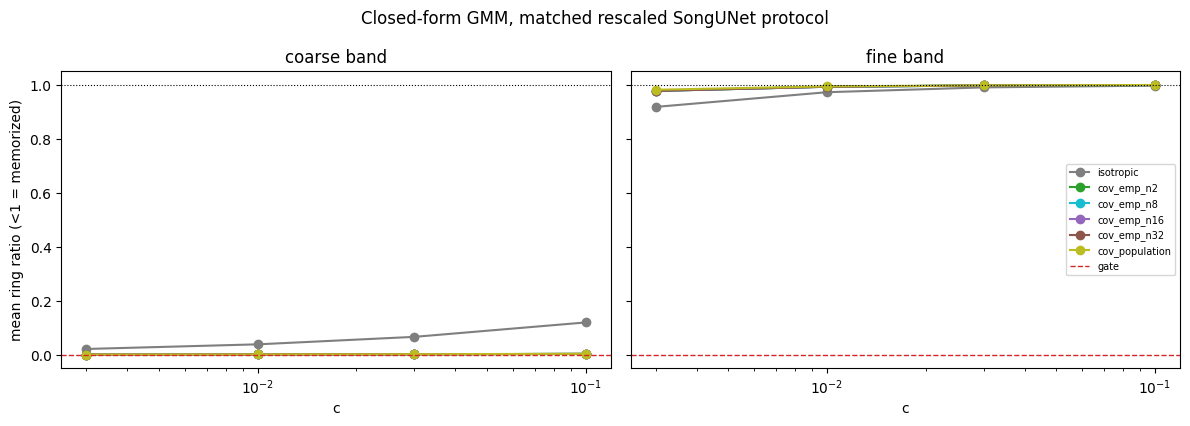

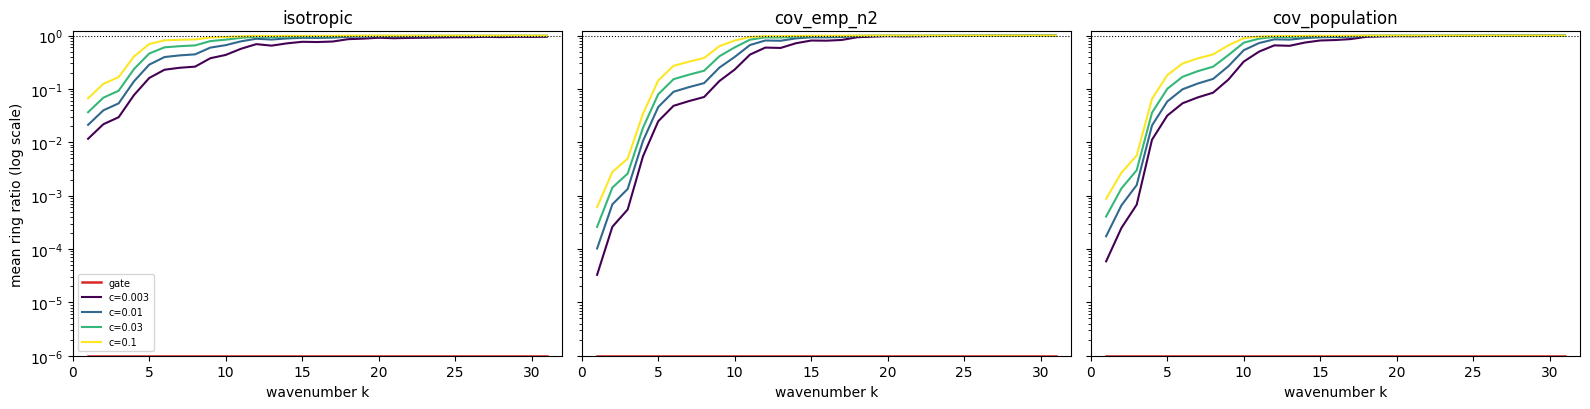

saved /Users/ishittaiyer/Desktop/research-diffusion/results/figures/gmm_rescaled_cov_tikhonov_band_scores_full.png
saved /Users/ishittaiyer/Desktop/research-diffusion/results/figures/gmm_rescaled_cov_tikhonov_per_k_full.png


In [7]:
variants = ['isotropic'] + [f'cov_emp_n{n}' for n in ESTIMATION_NS] + ['cov_population']
colors = dict(zip(variants, ['tab:gray', 'tab:green', 'tab:cyan', 'tab:purple',
                             'tab:brown', 'tab:olive']))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, band in zip(axes, ['coarse', 'fine']):
    for variant in variants:
        ys = [results[(variant, float(c))][f'{band}_score'] for c in C_VALUES]
        ax.plot(C_VALUES, ys, marker='o', color=colors[variant], label=variant)
    gate = results[('gate', 0.0)][f'{band}_score']
    ax.axhline(gate, color='tab:red', ls='--', lw=1, label='gate')
    ax.axhline(1.0, color='black', ls=':', lw=0.8)
    ax.set_xscale('log'); ax.set_xlabel('c'); ax.set_title(f'{band} band')
axes[0].set_ylabel('mean ring ratio (<1 = memorized)')
axes[1].legend(fontsize=7)
fig.suptitle('Closed-form GMM, matched rescaled SongUNet protocol')
fig.tight_layout()
f1 = os.path.join(fig_dir, f'gmm_rescaled_cov_tikhonov_band_scores_{run_tag}.png')
fig.savefig(f1, dpi=180, bbox_inches='tight')
plt.show()

k = metric_ctx.k_centers.cpu().numpy()
supported = k < 32  # the synthetic fields have no signal beyond the fine-band cutoff
plot_floor = 1e-6   # keep the nearly-zero gate curve visible on a log axis
show = ['isotropic', f'cov_emp_n{ESTIMATION_NS[0]}', 'cov_population']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, variant in zip(axes, show):
    gate_ratio = np.maximum(results[('gate', 0.0)]['mean_ratio'].numpy()[supported], plot_floor)
    ax.plot(k[supported], gate_ratio, color='tab:red', lw=1.8, label='gate')
    for j, c in enumerate(C_VALUES):
        ratio_k = np.maximum(results[(variant, float(c))]['mean_ratio'].numpy()[supported], plot_floor)
        ax.plot(k[supported], ratio_k,
                color=plt.cm.viridis(j / max(len(C_VALUES)-1, 1)), label=f'c={c:g}')
    ax.axhline(1, color='black', ls=':', lw=0.8)
    ax.set_yscale('log')
    ax.set_xlim(0, 31.99); ax.set_ylim(plot_floor, 1.2)
    ax.set_xlabel('wavenumber k'); ax.set_title(variant)
axes[0].set_ylabel('mean ring ratio (log scale)')
axes[0].legend(fontsize=7)
fig.tight_layout()
f2 = os.path.join(fig_dir, f'gmm_rescaled_cov_tikhonov_per_k_{run_tag}.png')
fig.savefig(f2, dpi=180, bbox_inches='tight')
plt.show()
print(f'saved {f1}\nsaved {f2}')


## Optional direct overlay with completed SongUNet arms

This cell adds no new experiment. Once the DRAC `.pt` files are copied back, it overlays the
final SongUNet and exact-GMM fine-band curves under identical settings.


In [8]:
import glob
song_dir = os.path.join(results_dir, 'songunet_cov_tikhonov')
song = {}
for path in glob.glob(os.path.join(song_dir, 'arm_*_result.pt')):
    item = torch.load(path, map_location='cpu', weights_only=False)
    name = os.path.basename(path)[4:-10]
    variant, c_text = name.rsplit('_c', 1)
    song[(variant, float(c_text))] = item

if song:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    compare = ['isotropic', f'cov_emp_n{ESTIMATION_NS[0]}', 'cov_population']
    for variant in compare:
        gmm_y = [results[(variant, float(c))]['fine_score'] for c in C_VALUES]
        ax.plot(C_VALUES, gmm_y, color=colors[variant], marker='o', ls='--',
                label=f'GMM {variant}')
        if all((variant, float(c)) in song for c in C_VALUES):
            net_y = [song[(variant, float(c))]['eval_log'][-1]['fine_score'] for c in C_VALUES]
            ax.plot(C_VALUES, net_y, color=colors[variant], marker='s', ls='-',
                    label=f'SongUNet {variant}')
    ax.set_xscale('log'); ax.axhline(1, color='black', ls=':', lw=0.8)
    ax.set_xlabel('c'); ax.set_ylabel('fine-band mean ratio'); ax.legend(fontsize=7)
    ax.set_title('Exact GMM vs trained SongUNet (matched protocol)')
    fig.tight_layout(); plt.show()
else:
    print('No completed SongUNet result files found locally; copy them back from DRAC first.')


No completed SongUNet result files found locally; copy them back from DRAC first.
